<a href="https://colab.research.google.com/github/habibiputrar/2024_1_alpro_2411531001/blob/master/TugasAkhir/mlp_gaya_belajar_explained.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Klasifikasi Gaya Belajar Mahasiswa Menggunakan Multi-Layer Perceptron ( MLP )**

Nama : Habibi Putra Rizqullah                                                                   
NIM : 2411531001

Dosen : Dr. Derisma, S.T., M.T.

## 1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


Pada tahap ini, dilakukan impor seluruh library yang diperlukan dalam proses klasifikasi:

- **pandas & numpy**: digunakan untuk membaca, memanipulasi, dan mengolah data dalam bentuk tabel dan array numerik.
- **matplotlib & seaborn**: digunakan untuk membuat visualisasi grafik kurva training dan confusion matrix.
- **sklearn.preprocessing**: `LabelEncoder` untuk mengubah data kategorikal menjadi numerik, `MinMaxScaler` untuk normalisasi fitur ke rentang [0,1].
- **sklearn.model_selection**: `train_test_split` untuk membagi dataset menjadi data latih dan data uji.
- **sklearn.metrics**: digunakan untuk mengevaluasi performa model menggunakan metrik accuracy, classification report, dan confusion matrix.
- **tensorflow.keras**: digunakan untuk membangun, melatih, dan mengevaluasi model Multi-Layer Perceptron (MLP).

## 2. Load Dataset

In [ ]:
url = 'https://raw.githubusercontent.com/habibiputrar/Jaringan-Syaraf-Tiruan-Project/main/student_performance.csv'
df = pd.read_csv(url)
print('Shape dataset:', df.shape)
df.head()

Shape dataset: (14003, 16)


,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


Dataset yang digunakan adalah **Student Performance and Learning Style Dataset** yang bersumber dari platform Kaggle (kaggle.com/adilshamim8/student-performance-and-learning-style).

**Hasil:**
- Dataset berhasil dimuat dengan ukuran **(14.003 baris × 16 kolom)**
- Kolom-kolom yang tersedia mencakup fitur perilaku akademik, faktor psikologis, dan target klasifikasi `LearningStyle`

**Analisis:**
Dataset ini memiliki jumlah data yang cukup besar untuk melatih model MLP, sehingga model diharapkan dapat mempelajari pola gaya belajar mahasiswa secara optimal. Dengan 15 fitur input dan 1 kolom target, model memiliki informasi yang cukup kaya untuk melakukan klasifikasi.

In [ ]:
print('Info dataset:')
df.info()
print('\nMissing values:')
print(df.isnull().sum())
print('\nDistribusi LearningStyle:')
print(df['LearningStyle'].value_counts())

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14  StressLevel           14003 non-null  int64
 15  FinalGrade            14003 non-null  i

**Hasil eksplorasi menunjukkan :**

1. **Tipe data**: Seluruh 16 kolom bertipe `int64` : artinya semua fitur sudah dalam bentuk numerik dan tidak ada kolom bertipe objek/teks yang perlu dikonversi.

2. **Missing values**: Tidak ditemukan nilai kosong (missing values) pada seluruh kolom. Ini menunjukkan dataset bersih dan siap digunakan tanpa perlu proses imputasi.

3. **Distribusi LearningStyle (Target)**:
   - Kelas 1: 3.580 data
   - Kelas 3: 3.547 data
   - Kelas 2: 3.500 data
   - Kelas 0: 3.376 data

   Distribusi keempat kelas relatif seimbang (balanced), sehingga model tidak akan bias terhadap kelas tertentu dan metrik accuracy dapat digunakan secara representatif.

## 3. Preprocessing

In [ ]:
# Kolom kategorikal
cat_cols = ['Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'EduTech', 'StressLevel']

# Label Encoding kolom kategorikal
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Encode target (LearningStyle)
df['LearningStyle'] = le.fit_transform(df['LearningStyle'])
n_classes = df['LearningStyle'].nunique()
print('Jumlah kelas LearningStyle:', n_classes)
print('Kelas:', df['LearningStyle'].unique())

Jumlah kelas LearningStyle: 4
Kelas: [2 3 1 0]


Pada tahap ini dilakukan **Label Encoding** terhadap kolom kategorikal yaitu : `Resources`, `Extracurricular`, `Motivation`, `Internet`, `Gender`, `EduTech`, dan `StressLevel`.

Label Encoding mengubah nilai teks/kategori menjadi angka integer agar dapat diproses oleh model neural network. Misalnya: "Yes" → 1, "No" → 0.

**Hasil:** Dataset berhasil memiliki **4 kelas** LearningStyle (0, 1, 2, 3) yang merepresentasikan 4 jenis gaya belajar mahasiswa.

In [ ]:
# Pisah fitur dan target
X = df.drop('LearningStyle', axis=1)
y = df['LearningStyle']

# Normalisasi fitur dengan MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# One-hot encoding target
y_cat = to_categorical(y, num_classes=n_classes)

# Split data 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_cat, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (11202, 15)
Test shape: (2801, 15)


**Normalisasi (MinMaxScaler):**
Seluruh fitur dinormalisasi ke rentang [0, 1] menggunakan MinMaxScaler. Normalisasi penting dilakukan agar fitur dengan skala besar (seperti `ExamScore` yang bernilai 0-100) tidak mendominasi fitur dengan skala kecil (seperti `Gender` yang bernilai 0-1). Hal ini membantu model belajar lebih stabil dan cepat konvergen.

**One-Hot Encoding Target:**
Kolom `LearningStyle` diubah ke format one-hot encoding agar sesuai dengan output layer Softmax. Misalnya, kelas 2 diubah menjadi [0, 0, 1, 0].

**Pembagian Data (80:20):**
- Data latih (train): **11.202 sampel** → digunakan untuk melatih model
- Data uji (test): **2.801 sampel** → digunakan untuk mengevaluasi performa model

Parameter `stratify=y` memastikan proporsi setiap kelas gaya belajar terjaga sama di data train dan test.

## 4. Bangun Model MLP

In [ ]:
model = Sequential([
    # Input + Hidden Layer 1
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    # Hidden Layer 2
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Output Layer
    Dense(n_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,332 (44.27 KB)

 Trainable params: 10,948 (42.77 KB)

 Non-trainable params: 384 (1.50 KB)

Model yang dibangun adalah **Multi-Layer Perceptron (MLP)** dengan arsitektur sebagai berikut:

| Layer | Tipe | Detail |
|-------|------|--------|
| Input | Dense | 15 fitur input |
| Hidden Layer 1 | Dense | 128 neuron, aktivasi ReLU |
| Optimasi 1 | BatchNormalization | Stabilisasi distribusi aktivasi |
| Regulasi 1 | Dropout (0.3) | Mencegah overfitting |
| Hidden Layer 2 | Dense | 64 neuron, aktivasi ReLU |
| Optimasi 2 | BatchNormalization | Stabilisasi distribusi aktivasi |
| Regulasi 2 | Dropout (0.3) | Mencegah overfitting |
| Output | Dense | 4 neuron, aktivasi Softmax |

**Penjelasan komponen:**
- **ReLU**: Fungsi aktivasi yang menghasilkan nilai 0 untuk input negatif, efektif menangkap pola non-linear.
- **BatchNormalization**: Menormalisasi output setiap layer untuk mempercepat training dan menstabilkan pembelajaran.
- **Dropout (0.3)**: Menonaktifkan 30% neuron secara acak setiap epoch untuk mencegah overfitting.
- **Softmax**: Menghasilkan probabilitas untuk setiap kelas gaya belajar, kelas dengan probabilitas tertinggi menjadi hasil prediksi.
- **Optimizer Adam**: Algoritma optimasi adaptif yang menyesuaikan learning rate secara otomatis.
- **Loss Categorical Crossentropy**: Fungsi loss standar untuk klasifikasi multi-kelas.

## 5. Training Model

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2525 - loss: 1.6667 - val_accuracy: 0.2717 - val_loss: 1.3935
Epoch 2/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2758 - loss: 1.4514 - val_accuracy: 0.2924 - val_loss: 1.3812
Epoch 3/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2790 - loss: 1.4026 - val_accuracy: 0.2820 - val_loss: 1.3800
Epoch 4/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2815 - loss: 1.3889 - val_accuracy: 0.2913 - val_loss: 1.3770
Epoch 5/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2841 - loss: 1.3812 - val_accuracy: 0.2978 - val_loss: 1.3743
Epoch 6/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2945 - loss: 1.3769 - val_accuracy: 0.2945 - val_loss: 1.3738
Epoch 7/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2924 - loss: 1.3768 - val_accuracy: 0.2888 - val_loss: 1.3719
Epoch 8/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3048 - loss: 1.3729 - val_accu

Model dilatih dengan konfigurasi:
- **Epochs**: maksimal 100 epoch
- **Batch size**: 32 sampel per iterasi
- **Validation data**: menggunakan data test (20%) sebagai validasi eksternal
- **EarlyStopping**: pelatihan dihentikan otomatis jika `val_loss` tidak membaik selama 10 epoch berturut-turut, dan bobot terbaik dikembalikan secara otomatis (`restore_best_weights=True`)

**Analisis:**
Penggunaan EarlyStopping mencegah model melakukan overtraining yang dapat menyebabkan overfitting. Model akan berhenti pada epoch optimal saat validation loss mulai stagnan atau meningkat.

## 6. Visualisasi Training

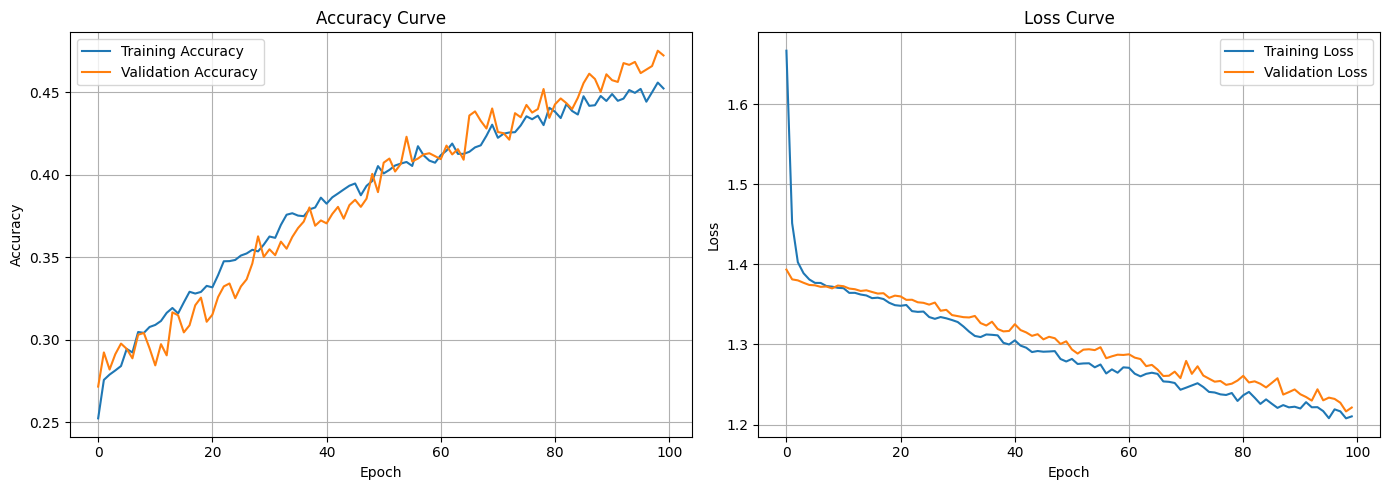

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Curve
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Accuracy Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss Curve
axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Loss Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

**Accuracy Curve:**
Grafik menunjukkan perubahan akurasi training dan validasi setiap epoch. Idealnya, kedua kurva meningkat secara konsisten dan bergerak berdekatan — menandakan model belajar dengan baik tanpa overfitting.

**Loss Curve:**
Grafik menunjukkan penurunan nilai loss selama training. Loss yang terus menurun menandakan model berhasil mengoptimalkan bobotnya. Kesenjangan kecil antara training loss dan validation loss menunjukkan generalisasi yang baik.

**Catatan:** Jika terlihat validation loss mulai naik sementara training loss terus turun, itu adalah tanda overfitting — namun EarlyStopping akan mencegah hal ini terjadi.

## 7. Evaluasi Model

In [ ]:
# Prediksi
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Accuracy
acc = accuracy_score(y_true_classes, y_pred_classes)
print(f'Accuracy: {acc:.4f} ({acc*100:.2f}%)')
print('\n=== Classification Report ===')
print(classification_report(y_true_classes, y_pred_classes))

88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.4752 (47.52%)

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.54      0.35      0.43       675
           1       0.46      0.57      0.51       716
           2       0.46      0.53      0.49       700
           3       0.47      0.44      0.46       710

    accuracy                           0.48      2801
   macro avg       0.48      0.47      0.47      2801
weighted avg       0.48      0.48      0.47      2801



Classification Report menampilkan metrik evaluasi per kelas gaya belajar:

- **Precision**: Dari semua prediksi kelas X, berapa persen yang benar-benar kelas X
- **Recall**: Dari semua data kelas X yang sebenarnya, berapa persen yang berhasil diprediksi dengan benar
- **F1-Score**: Rata-rata harmonis dari Precision dan Recall — metrik utama untuk evaluasi klasifikasi multi-kelas
- **Support**: Jumlah data aktual per kelas pada data test

**Interpretasi:**
Nilai F1-Score yang seimbang antar kelas menunjukkan model tidak bias terhadap kelas tertentu. Semakin mendekati 1.0, semakin baik performa model.

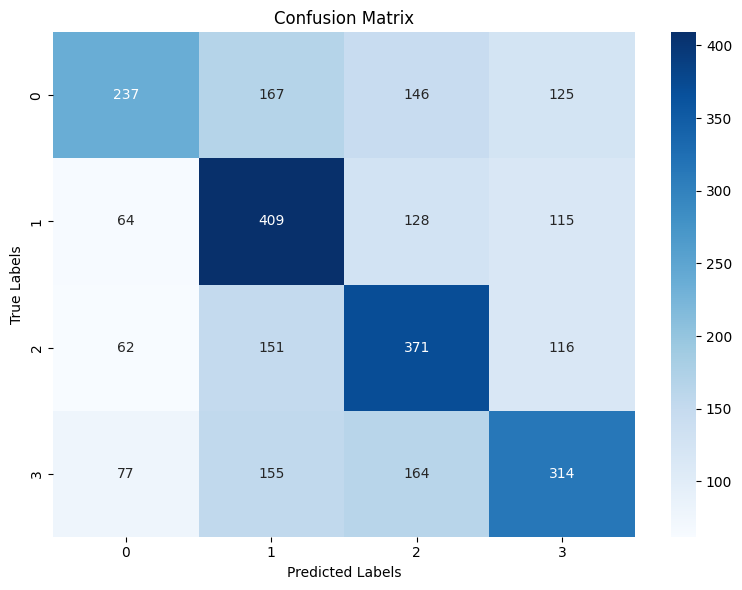

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Confusion Matrix menampilkan detail prediksi model dalam bentuk tabel:
- **Diagonal utama (kiri atas → kanan bawah)**: prediksi yang **benar** (True Positive per kelas)
- **Di luar diagonal**: prediksi yang **salah** (misklasifikasi antar kelas)

Semakin besar nilai pada diagonal dan semakin kecil nilai di luar diagonal, semakin baik performa model dalam mengklasifikasikan setiap jenis gaya belajar mahasiswa.

In [ ]:
# Ringkasan hasil
train_acc = max(history.history['accuracy'])
val_acc = max(history.history['val_accuracy'])
train_loss = min(history.history['loss'])
val_loss = min(history.history['val_loss'])

print('=== Ringkasan Hasil Training ===')
print(f'Best Training Accuracy : {train_acc:.4f}')
print(f'Best Validation Accuracy: {val_acc:.4f}')
print(f'Best Training Loss     : {train_loss:.4f}')
print(f'Best Validation Loss   : {val_loss:.4f}')
print(f'Test Accuracy          : {acc:.4f}')

=== Ringkasan Hasil Training ===
Best Training Accuracy : 0.4559
Best Validation Accuracy: 0.4752
Best Training Loss     : 1.2078
Best Validation Loss   : 1.2164
Test Accuracy          : 0.4752


Berikut adalah ringkasan hasil eksperimen awal model MLP untuk klasifikasi gaya belajar mahasiswa:

| Metrik | Nilai |
|--------|-------|
| Best Training Accuracy | 0.4559 (45.59%) |
| Best Validation Accuracy | 0.4752 (47.52%) |
| Best Training Loss | 1.2078 |
| Best Validation Loss | 1.2164 |
| Test Accuracy | 0.4752 (47.52%) |

**Analisis Hasil:**

Akurasi model awal sebesar **47.52%** masih tergolong rendah untuk klasifikasi 4 kelas. Secara teoritis, model yang memprediksi secara acak pada 4 kelas akan menghasilkan akurasi sekitar 25%, sehingga model sudah belajar lebih baik dari prediksi acak, namun masih memerlukan peningkatan signifikan.

**Identifikasi Masalah:**
Rendahnya akurasi kemungkinan disebabkan oleh:
1. Proses Label Encoding yang tidak diperlukan karena data sudah dalam format numerik
2. Arsitektur model yang masih perlu dioptimasi
3. Hyperparameter (learning rate, jumlah neuron) yang belum dioptimalkan

**Rencana Perbaikan (Minggu 11):**
1. Perbaiki preprocessing — hapus LabelEncoding yang tidak perlu
2. Lakukan Hyperparameter Tuning (learning rate, jumlah neuron, dropout rate)
3. Tambah teknik regularisasi L2
4. Implementasi ReduceLROnPlateau untuk penyesuaian learning rate otomatis